#### Load the data

In [ ]:
import pandas as pd

business = pd.read_csv('../data/raw/business.csv')
economy  = pd.read_csv('../data/raw/economy.csv')

print("Business shape:", business.shape)
print("Economy shape: ", economy.shape)

Business shape: (93487, 11)
Economy shape:  (206774, 11)


#### Display first 5 rows 

In [158]:
print("=== BUSINESS ===")
display(business.head())

print("=== ECONOMY ===")
display(economy.head())

=== BUSINESS ===


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,"25,612"
1,11-02-2022,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,"25,612"
2,11-02-2022,Air India,AI,531,20:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45,Mumbai,"42,220"
3,11-02-2022,Air India,AI,839,21:25,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"44,450"
4,11-02-2022,Air India,AI,544,17:15,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"46,690"


=== ECONOMY ===


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,"5,953"
1,11-02-2022,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,"5,953"
2,11-02-2022,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,"5,956"
3,11-02-2022,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,"5,955"
4,11-02-2022,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,"5,955"


#### Explore the data type for each column

In [159]:
print("=== BUSINESS ===")
print(business.dtypes)

print("\n=== ECONOMY ===")
print(economy.dtypes)

=== BUSINESS ===
date            str
airline         str
ch_code         str
num_code      int64
dep_time        str
from            str
time_taken      str
stop            str
arr_time        str
to              str
price           str
dtype: object

=== ECONOMY ===
date            str
airline         str
ch_code         str
num_code      int64
dep_time        str
from            str
time_taken      str
stop            str
arr_time        str
to              str
price           str
dtype: object


#### Explore null values

In [160]:
print("=== BUSINESS ===")
print(business.isnull().sum())

print("\n=== ECONOMY ===")
print(economy.isnull().sum())

=== BUSINESS ===
date          0
airline       0
ch_code       0
num_code      0
dep_time      0
from          0
time_taken    0
stop          0
arr_time      0
to            0
price         0
dtype: int64

=== ECONOMY ===
date          0
airline       0
ch_code       0
num_code      0
dep_time      0
from          0
time_taken    0
stop          0
arr_time      0
to            0
price         0
dtype: int64


#### Explore duplicated values 

In [161]:
print("Business duplicates:", business.duplicated().sum())
print("Economy duplicates:", economy.duplicated().sum())

Business duplicates: 0
Economy duplicates: 2


##### Display duplicated values before removing 

In [162]:
print("=== Duplicate rows in Economy ===")
display(economy[economy.duplicated(keep=False)])

=== Duplicate rows in Economy ===


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
516,14-02-2022,Air India,AI,807,17:20,Delhi,15h 15m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,08:35,Mumbai,"12,150"
563,14-02-2022,Air India,AI,807,17:20,Delhi,15h 15m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,08:35,Mumbai,"12,150"
6080,13-03-2022,Air India,AI,475,13:00,Delhi,24h 35m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,13:35,Mumbai,"4,780"
6181,13-03-2022,Air India,AI,475,13:00,Delhi,24h 35m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,13:35,Mumbai,"4,780"


##### Remove duplicated values 

In [163]:
economy = economy.drop_duplicates()
print("Economy shape after dropping duplicates:", economy.shape)

Economy shape after dropping duplicates: (206772, 11)


#### Explore unique values 

##### from here I notice that there is some companies just provide Economy class so we will take this info into considiration....

In [164]:
cat_cols = ['airline', 'from', 'to', 'stop', 'dep_time', 'arr_time']

for col in cat_cols:
    print(f"\n=== {col} ===")
    print("Business:", business[col].unique())
    print("Economy: ", economy[col].unique())
    


=== airline ===
Business: <StringArray>
['Air India', 'Vistara']
Length: 2, dtype: str
Economy:  <StringArray>
[ 'SpiceJet',   'AirAsia',   'Vistara',  'GO FIRST',    'Indigo', 'Air India',
    'Trujet',   'StarAir']
Length: 8, dtype: str

=== from ===
Business: <StringArray>
['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']
Length: 6, dtype: str
Economy:  <StringArray>
['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']
Length: 6, dtype: str

=== to ===
Business: <StringArray>
['Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai', 'Delhi']
Length: 6, dtype: str
Economy:  <StringArray>
['Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai', 'Delhi']
Length: 6, dtype: str

=== stop ===
Business: <StringArray>
[                                                                'non-stop ',
                '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t\t\t\t\t\t\t',
         '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia IDR\n\t\t\t\t\t\t\t\t\t\t\t\t',
      

#### Explore important values in price column 
##### But before this we must convert this from categorical data type to numerical type 

In [165]:
business['price'] = pd.to_numeric(business['price'].str.replace(',', ''), errors='coerce')
economy['price'] = pd.to_numeric(economy['price'].str.replace(',', ''), errors='coerce')

print("Business price:", business['price'].dtype)
print("Economy price: ", economy['price'].dtype)

Business price: int64
Economy price:  int64


In [166]:
print("=== BUSINESS price ===")
print(business['price'].describe().round())

print("\n=== ECONOMY price ===")
print(economy['price'].describe().round())

=== BUSINESS price ===
count     93487.0
mean      52540.0
std       12969.0
min       12000.0
25%       45185.0
50%       53164.0
75%       60396.0
max      123071.0
Name: price, dtype: float64

=== ECONOMY price ===
count    206772.0
mean       6571.0
std        3743.0
min        1105.0
25%        4173.0
50%        5772.0
75%        7746.0
max       42349.0
Name: price, dtype: float64


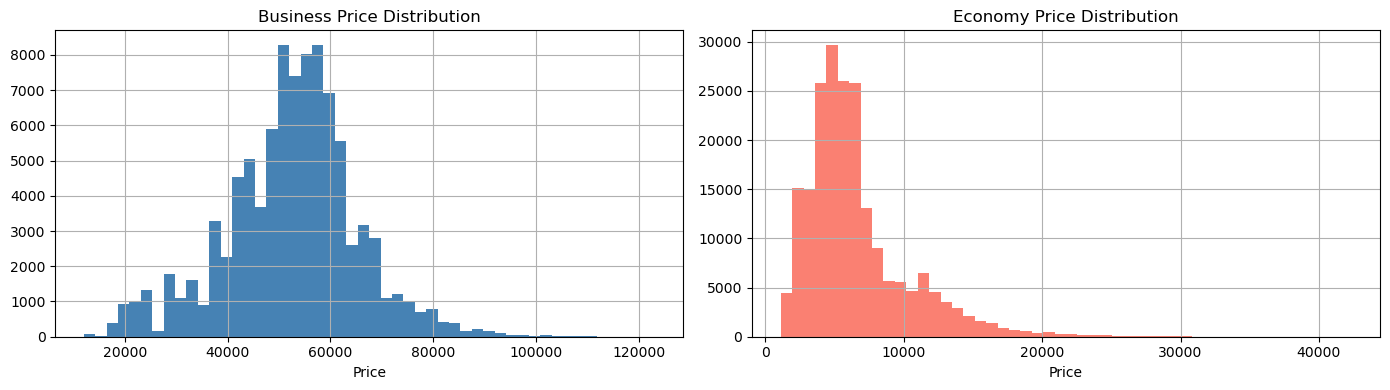

In [167]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

business['price'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Business Price Distribution')
axes[0].set_xlabel('Price')

economy['price'].hist(bins=50, ax=axes[1], color='salmon')
axes[1].set_title('Economy Price Distribution')
axes[1].set_xlabel('Price')

plt.tight_layout()
plt.show()

#### Work on Date column
##### First covert this column to date type instead of str 

In [168]:
business['date'] = pd.to_datetime(business['date'], format='%d-%m-%Y')
economy['date']  = pd.to_datetime(economy['date'],  format='%d-%m-%Y')

print("Business date range:", business['date'].min(), "→", business['date'].max())
print("Economy date range: ", economy['date'].min(), "→", economy['date'].max())
print("\nBusiness date dtype:", business['date'].dtype) # to make sure that the date is in datetime format
print("Economy date dtype: ", economy['date'].dtype)

Business date range: 2022-02-11 00:00:00 → 2022-03-31 00:00:00
Economy date range:  2022-02-11 00:00:00 → 2022-03-31 00:00:00

Business date dtype: datetime64[us]
Economy date dtype:  datetime64[us]


In [169]:
print("Business date sample:")
print(business['date'].unique()[:10])

print("\nEconomy date sample:")
print(economy['date'].unique()[:10])


Business date sample:
<DatetimeArray>
['2022-02-11 00:00:00', '2022-02-12 00:00:00', '2022-02-13 00:00:00',
 '2022-02-14 00:00:00', '2022-02-15 00:00:00', '2022-02-16 00:00:00',
 '2022-02-17 00:00:00', '2022-02-18 00:00:00', '2022-02-19 00:00:00',
 '2022-02-20 00:00:00']
Length: 10, dtype: datetime64[us]

Economy date sample:
<DatetimeArray>
['2022-02-11 00:00:00', '2022-02-12 00:00:00', '2022-02-13 00:00:00',
 '2022-02-14 00:00:00', '2022-02-15 00:00:00', '2022-02-16 00:00:00',
 '2022-02-17 00:00:00', '2022-02-18 00:00:00', '2022-02-19 00:00:00',
 '2022-02-20 00:00:00']
Length: 10, dtype: datetime64[us]


#### Working on Stops column because it contains garbege \t\t\t text

In [170]:
# remove all tabs/newlines from the whole string
business['stop_clean'] = business['stop'].str.replace(r'\s+', ' ', regex=True).str.strip()
economy['stop_clean'] = economy['stop'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [171]:
print("=== BUSINESS stop unique values ===")
print(business['stop_clean'].unique())

print("\n=== ECONOMY stop unique values ===")
print(economy['stop_clean'].unique())

=== BUSINESS stop unique values ===
<StringArray>
[              'non-stop',                 '1-stop',         '1-stop Via IDR',
         '1-stop Via IXU',     '1-stop Via Chennai',     '1-stop Via Lucknow',
         '1-stop Via STV',   '1-stop Via Hyderabad',         '1-stop Via GAY',
                '2+-stop',    '1-stop Via Guwahati',         '1-stop Via GAU',
         '1-stop Via VTZ',         '1-stop Via NDC',         '1-stop Via IXE',
      '1-stop Via Raipur',         '1-stop Via PAT',         '1-stop Via RPR',
       '1-stop Via Patna',     '1-stop Via Kolkata',         '1-stop Via HYD',
       '1-stop Via Delhi', '1-stop Via Bhubaneswar',         '1-stop Via BBI',
       '1-stop Via Surat']
Length: 25, dtype: str

=== ECONOMY stop unique values ===
<StringArray>
[                 'non-stop',                    '1-stop',
            '1-stop Via IXU',        '1-stop Via Chennai',
         '1-stop Via Indore',            '1-stop Via RPR',
                   '2+-stop',        '1-s

##### I decide here to drop the name of the stop city why ?? becuse there is many rows without this info like just saying 1-stop without mention the name of stoped city and this may cause many null values in DataSet 

In [172]:
def encode_stops(stop_series):
    clean = stop_series.str.replace(r'\s+', ' ', regex=True).str.strip()
    mapping = {
        'non-stop': 0,
    }
    def parse(val):
        if 'non-stop' in val:
            return 0
        elif '2+' in val or '2-stop' in val:
            return 2
        elif '1-stop' in val:
            return 1
        else:
            return None
    return clean.apply(parse)

business['stops_numeric'] = encode_stops(business['stop_clean'])
economy['stops_numeric']  = encode_stops(economy['stop_clean'])

print("Business stops distribution:")
print(business['stops_numeric'].value_counts())

print("\nEconomy stops distribution:")
print(economy['stops_numeric'].value_counts())

Business stops distribution:
stops_numeric
1    84302
0     8102
2     1083
Name: count, dtype: int64

Economy stops distribution:
stops_numeric
1    166625
0     27942
2     12205
Name: count, dtype: int64


In [173]:
print("Business null stops:", business['stops_numeric'].isnull().sum())
print("Economy null stops: ", economy['stops_numeric'].isnull().sum())

Business null stops: 0
Economy null stops:  0


##### drop stop and initilize new stop_clean column 

In [174]:
business = business.drop(columns=['stop', 'stop_clean'])
economy  = economy.drop(columns=['stop', 'stop_clean'])

print("Business columns:", business.columns.tolist())
print("Economy columns: ", economy.columns.tolist())

Business columns: ['date', 'airline', 'ch_code', 'num_code', 'dep_time', 'from', 'time_taken', 'arr_time', 'to', 'price', 'stops_numeric']
Economy columns:  ['date', 'airline', 'ch_code', 'num_code', 'dep_time', 'from', 'time_taken', 'arr_time', 'to', 'price', 'stops_numeric']


#### Drop the ch_code and num_code because they contain useless information and may affect our model negatively. 

In [175]:
business = business.drop(columns=['ch_code', 'num_code'])
economy  = economy.drop(columns=['ch_code', 'num_code'])

print("Business columns:", business.columns.tolist())
print("Economy columns: ", economy.columns.tolist())

Business columns: ['date', 'airline', 'dep_time', 'from', 'time_taken', 'arr_time', 'to', 'price', 'stops_numeric']
Economy columns:  ['date', 'airline', 'dep_time', 'from', 'time_taken', 'arr_time', 'to', 'price', 'stops_numeric']


#### Convert time_token column to minutes and save result in duration_minutes column


In [176]:
def convert_time_to_minutes(time_series):
    # Extract hours and minutes using regex
    hours   = (time_series.str.extract(r'(\d+)h', expand=False).fillna(0).astype(int))
    minutes = (time_series.str.extract(r'(\d+)m', expand=False).fillna(0).astype(int))
    return hours * 60 + minutes

business['duration_minutes'] = convert_time_to_minutes(business['time_taken'])
economy['duration_minutes']  = convert_time_to_minutes(economy['time_taken'])

print(business[['time_taken', 'duration_minutes']].head(10))
print(economy[['time_taken', 'duration_minutes']].head(10))

  time_taken  duration_minutes
0    02h 00m               120
1    02h 15m               135
2    24h 45m              1485
3    26h 30m              1590
4    06h 40m               400
5    02h 10m               130
6    17h 45m              1065
7    22h 45m              1365
8    17h 55m              1075
9    02h 15m               135
  time_taken  duration_minutes
0    02h 10m               130
1    02h 20m               140
2    02h 10m               130
3    02h 15m               135
4    02h 20m               140
5    02h 20m               140
6    02h 05m               125
7    02h 10m               130
8    02h 10m               130
9    02h 15m               135


##### drop time_taken column 

In [177]:
business = business.drop(columns=['time_taken'])
economy  = economy.drop(columns=['time_taken'])

#### Enhancing dep_time and arr_time columns 

In [178]:
business['departure_hour'] = pd.to_numeric(business['dep_time'].str[:2])
business['arrival_hour']   = pd.to_numeric(business['arr_time'].str[:2])

economy['departure_hour'] = pd.to_numeric(economy['dep_time'].str[:2])
economy['arrival_hour']   = pd.to_numeric(economy['arr_time'].str[:2])



In [179]:
business = business.drop(columns=['dep_time', 'arr_time'])
economy  = economy.drop(columns=['dep_time', 'arr_time'])


In [180]:
print("Business columns:", business.columns.tolist())
print("Economy columns: ", economy.columns.tolist())

Business columns: ['date', 'airline', 'from', 'to', 'price', 'stops_numeric', 'duration_minutes', 'departure_hour', 'arrival_hour']
Economy columns:  ['date', 'airline', 'from', 'to', 'price', 'stops_numeric', 'duration_minutes', 'departure_hour', 'arrival_hour']


In [181]:
business.dtypes

date                datetime64[us]
airline                        str
from                           str
to                             str
price                        int64
stops_numeric                int64
duration_minutes             int64
departure_hour               int64
arrival_hour                 int64
dtype: object

#### Feature Engineering Date column 

In [182]:
business['month'] = business['date'].dt.month
business['day'] = business['date'].dt.day_of_week
business['is_weekend'] = business['day'].isin([5, 6]).astype(int)

economy['month'] = economy['date'].dt.month
economy['day'] = economy['date'].dt.day_of_week
economy['is_weekend'] = economy['day'].isin([5, 6]).astype(int)





In [183]:
print(business[['date', 'month', 'day', 'is_weekend']].head())
print(economy[['date', 'month', 'day', 'is_weekend']].head())

        date  month  day  is_weekend
0 2022-02-11      2    4           0
1 2022-02-11      2    4           0
2 2022-02-11      2    4           0
3 2022-02-11      2    4           0
4 2022-02-11      2    4           0
        date  month  day  is_weekend
0 2022-02-11      2    4           0
1 2022-02-11      2    4           0
2 2022-02-11      2    4           0
3 2022-02-11      2    4           0
4 2022-02-11      2    4           0


In [184]:
business = business.drop(columns=['date'])
economy  = economy.drop(columns=['date'])

In [185]:

print("Business columns:", business.columns.tolist())
print("Economy columns: ", economy.columns.tolist())

Business columns: ['airline', 'from', 'to', 'price', 'stops_numeric', 'duration_minutes', 'departure_hour', 'arrival_hour', 'month', 'day', 'is_weekend']
Economy columns:  ['airline', 'from', 'to', 'price', 'stops_numeric', 'duration_minutes', 'departure_hour', 'arrival_hour', 'month', 'day', 'is_weekend']


In [186]:
print("Airlines - Business:", business['airline'].unique())
print("Airlines - Economy: ", economy['airline'].unique())

print("\nCities - from:", business['from'].unique())
print("Cities - to:  ", business['to'].unique())

Airlines - Business: <StringArray>
['Air India', 'Vistara']
Length: 2, dtype: str
Airlines - Economy:  <StringArray>
[ 'SpiceJet',   'AirAsia',   'Vistara',  'GO FIRST',    'Indigo', 'Air India',
    'Trujet',   'StarAir']
Length: 8, dtype: str

Cities - from: <StringArray>
['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']
Length: 6, dtype: str
Cities - to:   <StringArray>
['Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai', 'Delhi']
Length: 6, dtype: str


#### Visualize price column to get some insights

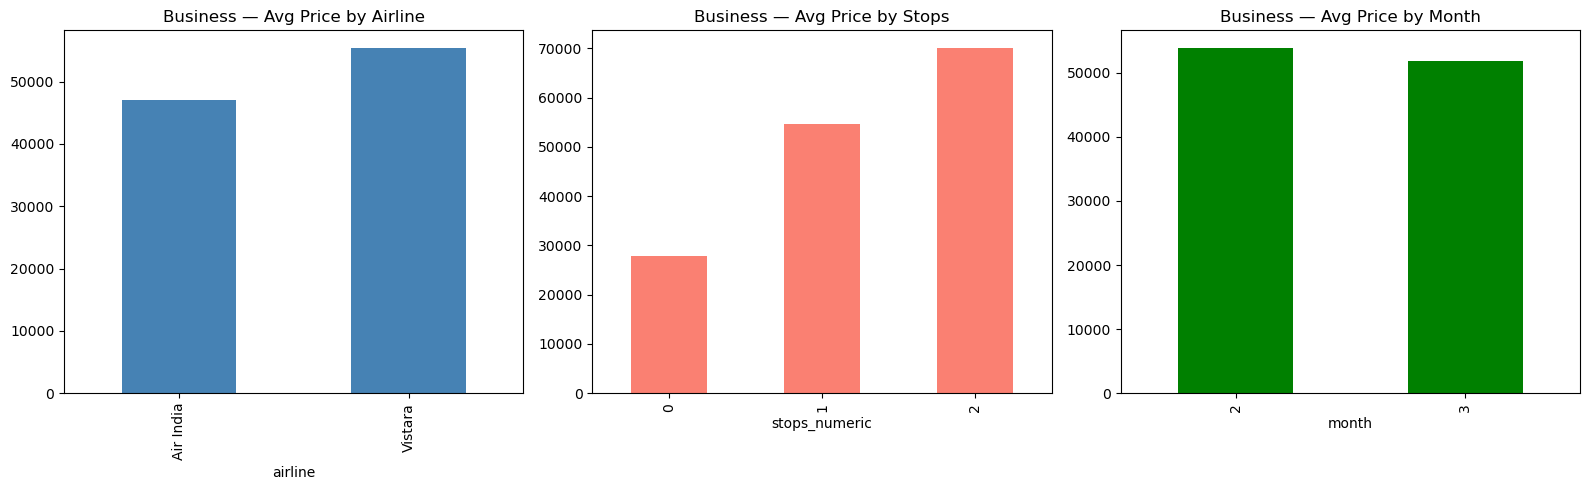

In [187]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

business.groupby('airline')['price'].mean().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Business — Avg Price by Airline')

business.groupby('stops_numeric')['price'].mean().plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Business — Avg Price by Stops')

business.groupby('month')['price'].mean().plot(kind='bar', ax=axes[2], color='green')
axes[2].set_title('Business — Avg Price by Month')

plt.tight_layout()
plt.show()

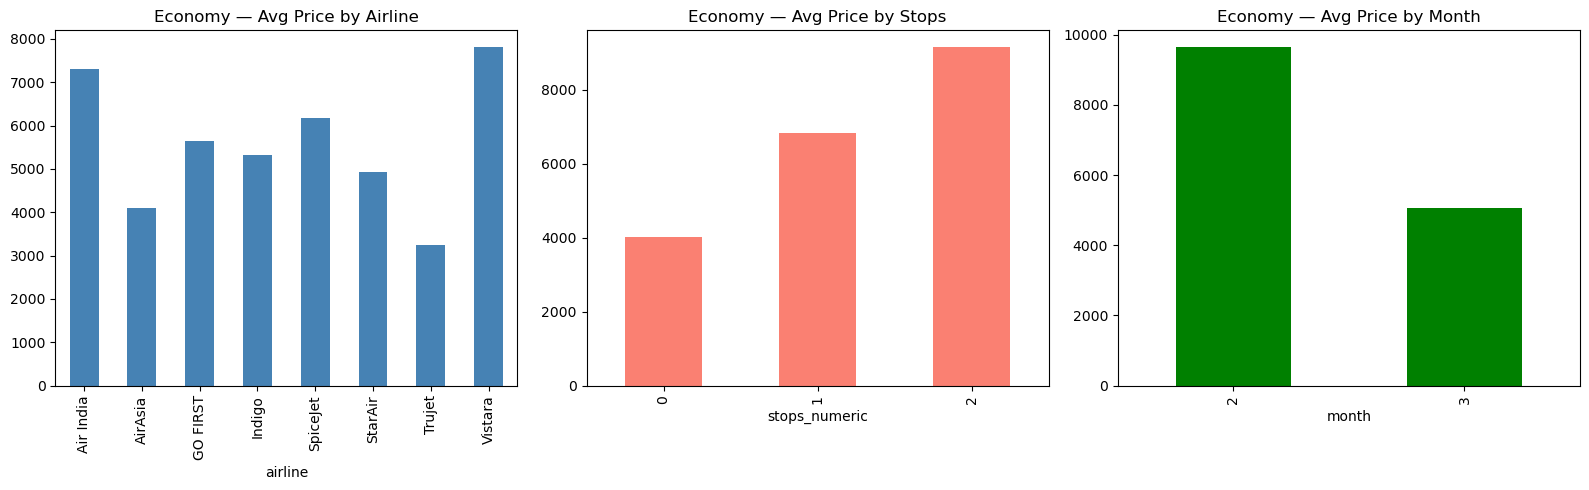

In [188]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

economy.groupby('airline')['price'].mean().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Economy — Avg Price by Airline')

economy.groupby('stops_numeric')['price'].mean().plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Economy — Avg Price by Stops')

economy.groupby('month')['price'].mean().plot(kind='bar', ax=axes[2], color='green')
axes[2].set_title('Economy — Avg Price by Month')

plt.tight_layout()
plt.show()

#### Explore differentiation between from to and to from columns logic

##### for example : flight from Delhi to Mumbai roughly save avg prices as flight from Mumbai to Delhi   

In [189]:
business['route'] = business['from'] + ' → ' + business['to']
economy['route']  = economy['from'] + ' → ' + economy['to']

print("Business routes:")
print(business.groupby('route')['price'].mean().sort_values(ascending=False))

print("\nEconomy routes:")
print(economy.groupby('route')['price'].mean().sort_values(ascending=False))


Business routes:
route
Bangalore → Kolkata      58854.693091
Kolkata → Bangalore      58681.104437
Bangalore → Mumbai       58024.618208
Mumbai → Bangalore       57970.544389
Kolkata → Mumbai         57422.551724
Mumbai → Kolkata         57106.526385
Chennai → Kolkata        57078.895872
Kolkata → Chennai        56502.775035
Delhi → Kolkata          56239.853659
Chennai → Mumbai         56223.838086
Mumbai → Chennai         55703.326197
Kolkata → Delhi          55047.492193
Kolkata → Hyderabad      54732.447908
Hyderabad → Kolkata      53729.157762
Chennai → Bangalore      53113.008692
Chennai → Delhi          52443.367242
Bangalore → Chennai      52436.915395
Hyderabad → Mumbai       52184.424666
Delhi → Chennai          52031.778099
Mumbai → Hyderabad       51593.643678
Chennai → Hyderabad      51559.874283
Hyderabad → Chennai      51132.155288
Bangalore → Hyderabad    50395.796948
Hyderabad → Bangalore    50358.290706
Delhi → Bangalore        48576.027921
Bangalore → Delhi        48

##### delete route column because it is just for exploration 

In [190]:
business = business.drop(columns=['route'])
economy  = economy.drop(columns=['route'])

#### make sure every thing is correct before merging 

In [191]:
print("=== BUSINESS ===")
print(business.shape)
print(business.dtypes)

print("\n=== ECONOMY ===")
print(economy.shape)
print(economy.dtypes)

=== BUSINESS ===
(93487, 11)
airline               str
from                  str
to                    str
price               int64
stops_numeric       int64
duration_minutes    int64
departure_hour      int64
arrival_hour        int64
month               int32
day                 int32
is_weekend          int64
dtype: object

=== ECONOMY ===
(206772, 11)
airline               str
from                  str
to                    str
price               int64
stops_numeric       int64
duration_minutes    int64
departure_hour      int64
arrival_hour        int64
month               int32
day                 int32
is_weekend          int64
dtype: object


#### Now Merging Economy + Business 
##### But before merging we must make the column that will differentiate between them which is (is_business) column

In [192]:
business['is_business'] = 1
economy['is_business']  = 0

In [193]:
df = pd.concat([business, economy], ignore_index=True)

print("Combined shape:", df.shape)
print("is_business distribution:")
print(df['is_business'].value_counts())

Combined shape: (300259, 12)
is_business distribution:
is_business
0    206772
1     93487
Name: count, dtype: int64


#### Decision: Retained apparent duplicates post-merge
Duplicates arose from reducing dep_time/arr_time to hour-level granularity
and dropping date in favor of month/day_of_week. These rows represent 
real flights and were kept to preserve dataset size and pattern frequency.

In [194]:
print("Any nulls?")
print(df.isnull().sum())

print("\nAny duplicates?", df.duplicated().sum())

print("\nPrice range:", df['price'].min(), "→", df['price'].max())

print("\nFinal columns:")
print(df.dtypes)

Any nulls?
airline             0
from                0
to                  0
price               0
stops_numeric       0
duration_minutes    0
departure_hour      0
arrival_hour        0
month               0
day                 0
is_weekend          0
is_business         0
dtype: int64

Any duplicates? 120945

Price range: 1105 → 123071

Final columns:
airline               str
from                  str
to                    str
price               int64
stops_numeric       int64
duration_minutes    int64
departure_hour      int64
arrival_hour        int64
month               int32
day                 int32
is_weekend          int64
is_business         int64
dtype: object


##### save processed data in other .csv file

In [196]:
df.to_csv('../data/processed/flights_cleaned.csv', index=False)
print("Saved successfully!")
print("Shape:", df.shape)

Saved successfully!
Shape: (300259, 12)


In [197]:
processed_data = pd.read_csv('../data/processed/flights_cleaned.csv')
